# Estimation of Sales Revenue based on Advertisement Budgets across various channels

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# package versions used to verify to create a virtual environment:
# np.__version__
# # '2.3.4'
# pd.__version__
# # '2.3.3'
# matplotlib.__version__
# # '3.10.7'
# sns.__version__
# # '0.13.2'
# sklearn.__version__
# # '1.7.2'
# xgboost.__version__
# # '3.1.1'

In [3]:
# importing sales revenue data
adsales_df = pd.read_csv('data/advertising_and_sales_clean.csv')

adsales_df.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [4]:
# info about the df
adsales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4546 entries, 0 to 4545
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   tv            4546 non-null   float64
 1   radio         4546 non-null   float64
 2   social_media  4546 non-null   float64
 3   influencer    4546 non-null   object 
 4   sales         4546 non-null   float64
dtypes: float64(4), object(1)
memory usage: 177.7+ KB


In [5]:
# stats of each col in df
adsales_df.describe(include='all')

,tv,radio,social_media,influencer,sales
count,4546.000000,4546.000000,4546.000000,4546,4546.000000
unique,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,Mega,NaN
freq,NaN,NaN,NaN,1152,NaN
mean,54062.912451,18157.533110,3323.472829,NaN,192413.332112
std,26104.941838,9663.259642,2211.253915,NaN,93019.873216
min,10000.000000,0.680000,0.030000,NaN,31199.410000
25%,32000.000000,10555.355000,1530.822500,NaN,112434.610000
50%,53000.000000,17859.515000,3055.565000,NaN,188963.680000
75%,77000.000000,25640.605000,4804.922500,NaN,272324.240000


In [6]:
# shape of the initial dataframe
adsales_df.shape

(4546, 5)

## 1. Data Cleaning

In [7]:
# checking empty cells
adsales_df.isnull().sum()

tv              0
radio           0
social_media    0
influencer      0
sales           0
dtype: int64

In [8]:
# checking duplicate records
print('number of duplicate records:', int(adsales_df.duplicated().sum()))

number of duplicate records: 0


In [9]:
# name of the feature and target columns to check if it is in lowercase
list(adsales_df.columns)

['tv', 'radio', 'social_media', 'influencer', 'sales']

# 2. EDA

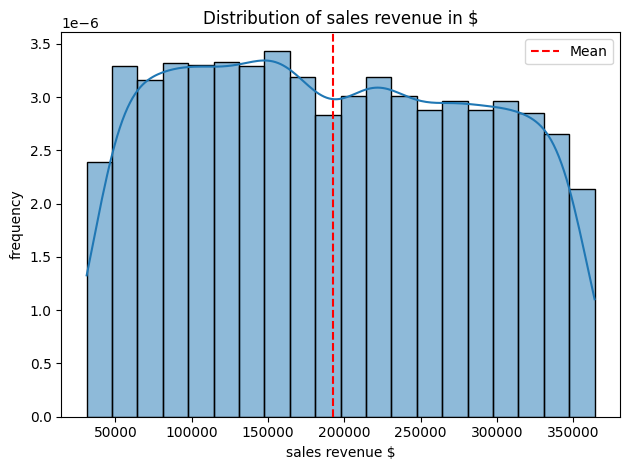

In [10]:
# distribution of the target variable --> sales revenue

# plotting the distribution
sns.histplot(adsales_df['sales'], bins=20, kde=True, stat='density', edgecolor='black')


plt.title('Distribution of sales revenue in $')
plt.xlabel('sales revenue $')
plt.ylabel('frequency')
plt.axvline(adsales_df['sales'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.tight_layout()

plt.show()

The target variable 'sales' revenue is almost uniformly distributed

In [11]:
# differentiating categorical and numerical features
# categorical features
cat_features  = list(adsales_df.select_dtypes(include=['object', 'category']).columns)

print('Categorical features:')
print(len(cat_features))
print(cat_features)
print()

# numerical features
num_features = list(adsales_df.select_dtypes(include=np.number).columns)

# removing the target
num_features.remove('sales') 

print('Numerical features:')
print(len(num_features))
print(num_features)

Categorical features:
1
['influencer']

Numerical features:
3
['tv', 'radio', 'social_media']


In [12]:
# unique values of categorical variable 'influencer'
print('Unique values of "influencer" feature: ')
print(adsales_df['influencer'].unique())
print(len(adsales_df['influencer'].unique()))

Unique values of "influencer" feature: 
['Mega' 'Micro' 'Nano' 'Macro']
4


Influencer categorized tiers explained:
<br><br>
Mega	1M+ followers <br>
Macro	100K–1M followers <br>
Micro	10K–100K followers <br>
Nano	1K–10K followers

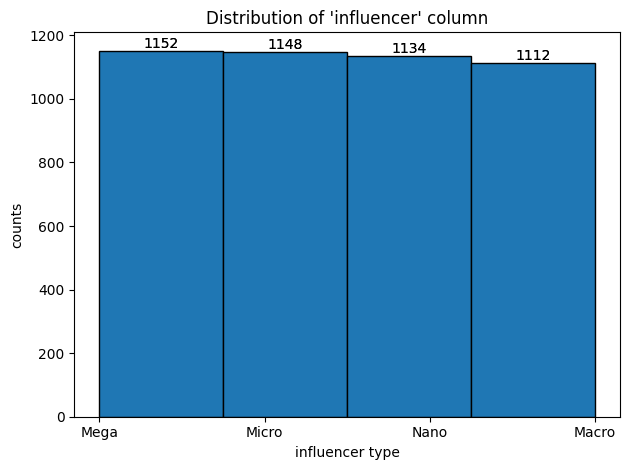

In [13]:
# distribution of the categorical feature 'influecer'
counts, bins, patches = plt.hist(adsales_df["influencer"], 
                                 bins=len(adsales_df["influencer"].unique()), 
                                 edgecolor='black')

# Count labels on bars
plt.bar_label(patches)

plt.title('Distribution of \'influencer\' column')
plt.xlabel('influencer type')
plt.ylabel('counts')

# Additional text labels (optional, since bar_label already shows counts)
for count, x in zip(counts, bins):
    if count > 0:
        plt.text(x + (bins[1]-bins[0])/2, count, str(int(count)), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [14]:
adsales_df['influencer'].value_counts()

influencer
Mega     1152
Micro    1148
Nano     1134
Macro    1112
Name: count, dtype: int64

The 'influencer' categorical feature is almost balanced